In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import xgboost as xgb
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Loading the training and test data
train = pd.read_csv('/Users/darrenbarkins/MSBA/ADML/data/midterm_train.csv')
test  = pd.read_csv('/Users/darrenbarkins/MSBA/ADML/data/midterm_test.csv')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Train shape: (32950, 23)
Test shape:  (8238, 22)


## Exploratory Data Analysis

Before I start building any models, I want to understand the data.
I'm looking at the shape of the target variable, how the features are distributed,
and whether anything stands out that might affect my modeling decisions.

Target Distribution:
accepted_offer
0    29235
1     3715
Name: count, dtype: int64

Acceptance rate: 11.3%


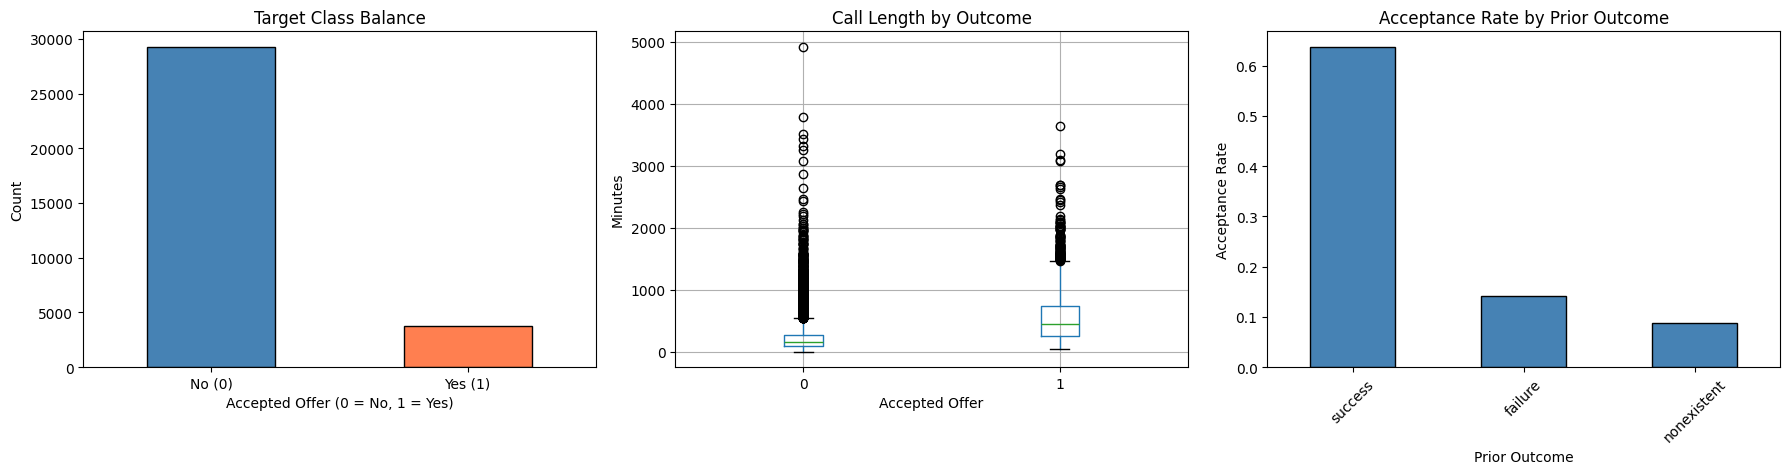


Average values by outcome:
                customer_age  contact_time_minutes  contact_attempt_count  \
accepted_offer                                                              
0                      39.90                220.35                   2.62   
1                      40.94                548.55                   2.05   

                prior_contact_count  consumer_confidence_index  \
accepted_offer                                                   
0                              0.13                     -40.59   
1                              0.49                     -39.85   

                reference_interest_rate  
accepted_offer                           
0                                  3.81  
1                                  2.11  


In [3]:
# Seeing how balanced the target variable is
print("Target Distribution:")
print(train['accepted_offer'].value_counts())
print()
print(f"Acceptance rate: {train['accepted_offer'].mean():.1%}")

# Plotting the class split so it's easy to see
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class balance bar chart
train['accepted_offer'].value_counts().plot(kind='bar', ax=axes[0],
      color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Target Class Balance')
axes[0].set_xlabel('Accepted Offer (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

# Contact time vs acceptance (longer calls might mean more interest)
train.boxplot(column='contact_time_minutes', by='accepted_offer', ax=axes[1])
axes[1].set_title('Call Length by Outcome')
axes[1].set_xlabel('Accepted Offer')
axes[1].set_ylabel('Minutes')
plt.sca(axes[1])
plt.title('Call Length by Outcome')

# Prior outcome status, did past success predict future success?
outcome_rate = train.groupby('prior_outcome_status')['accepted_offer'].mean().sort_values(ascending=False)
outcome_rate.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Acceptance Rate by Prior Outcome')
axes[2].set_xlabel('Prior Outcome')
axes[2].set_ylabel('Acceptance Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Quick look at how the numeric features relate to the target
print("\nAverage values by outcome:")
numeric_cols = ['customer_age', 'contact_time_minutes', 'contact_attempt_count',
                'prior_contact_count', 'consumer_confidence_index', 'reference_interest_rate']
print(train.groupby('accepted_offer')[numeric_cols].mean().round(2))

## Data Preparation

Since there are no missing values,
the main focus is encoding the categorical columns into numbers and
separating the features from the target variable.
Applying the same steps to both the training and test sets.

In [4]:
# Pulling out the list of categorical columns I need to encode
cat_cols = ['occupation_type', 'relationship_status', 'education_background',
            'has_credit_issue', 'mortgage_status', 'personal_loan_status',
            'last_contact_month', 'day_of_week', 'prior_outcome_status']

# Making copies so I don't accidentally change the original data
train_df = train.copy()
test_df  = test.copy()

# Using Label Encoding to turn text categories into numbers
# I'm fitting on the training data and applying the same mapping to the test data
le = LabelEncoder()
for col in cat_cols:
    # Combine train and test so the encoder sees all possible values
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

# Separating features (X) and target (y)
# Dropping id and the target from the feature set
X = train_df.drop(columns=['id', 'accepted_offer'])
y = train_df['accepted_offer']
X_test = test_df.drop(columns=['id'])

print("Feature matrix shape:", X.shape)
print("Test feature matrix shape:", X_test.shape)
print("Target shape:", y.shape)
print("\nClass balance in target:")
print(y.value_counts())

Feature matrix shape: (32950, 21)
Test feature matrix shape: (8238, 21)
Target shape: (32950,)

Class balance in target:
accepted_offer
0    29235
1     3715
Name: count, dtype: int64


## Feature Engineering or Feature Selection

I noticed that `days_since_prior_contact` uses 999 as a special code
meaning the customer had no prior contact at all.
I'm turning that into its own yes/no flag since it carries a different
meaning than an actual number of days.

I'll check whether adding this feature improves a baseline model,
and using feature importance to see if any columns can be dropped.

Customers with no prior contact (train): 31714
Customers with no prior contact (test):  7959


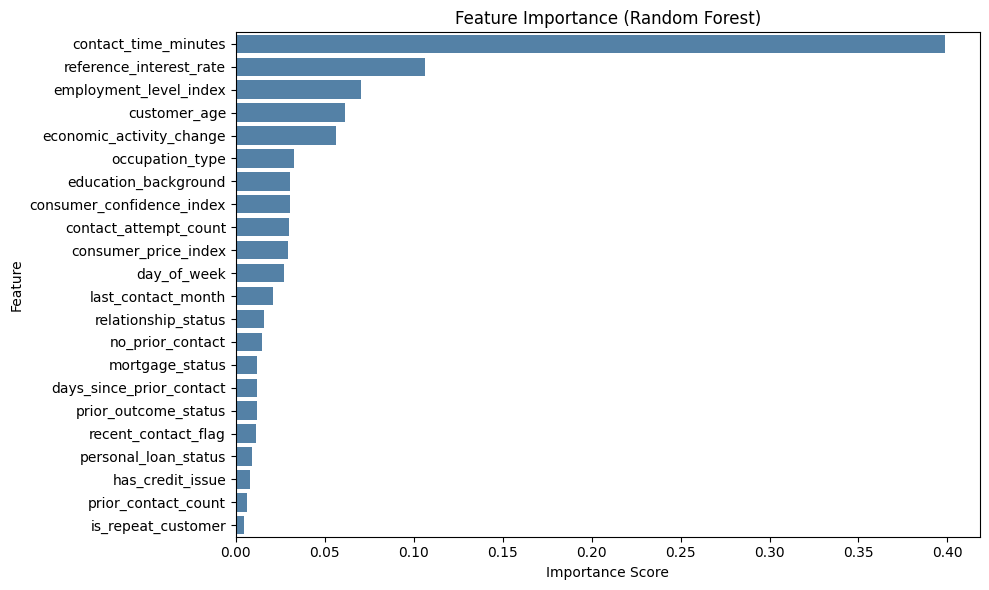


Bottom 3 features by importance:
            feature  importance
   has_credit_issue    0.008140
prior_contact_count    0.006447
 is_repeat_customer    0.004527


In [5]:
# Adding a flag for customers who were never contacted before
# 999 is a placeholder meaning "no prior contact" (not an actual day count)
X['no_prior_contact'] = (X['days_since_prior_contact'] == 999).astype(int)
X_test['no_prior_contact'] = (X_test['days_since_prior_contact'] == 999).astype(int)

# Quick check (how many customers fall into this group?)
print("Customers with no prior contact (train):", X['no_prior_contact'].sum())
print("Customers with no prior contact (test): ", X_test['no_prior_contact'].sum())

# I'll use a simple Random Forest to rank which features matter most
from sklearn.ensemble import RandomForestClassifier

rf_check = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_check.fit(X, y)

# Putting the importance scores into a table and sorting them
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_check.feature_importances_
}).sort_values('importance', ascending=False)

# Plotting the top features so it's easy to read
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nBottom 3 features by importance:")
print(importance_df.tail(3).to_string(index=False))

## Modeling and Evaluation

- **Random Forest** - builds many decision trees independently and averages their results
- **XGBoost** - builds trees one at a time, where each new tree tries to fix the mistakes of the last

Both models are tuned using Optuna, which automatically searches for the best settings.
I'm using **Stratified K-Fold CV (5 folds)** to make sure each fold
has the same class ratio as the full dataset.

Because only 11% of customers accepted the offer, accuracy alone would be misleading.
I'm using **ROC-AUC** as my main metric because it measures how well the model separates
the two groups regardless of the class imbalance.

In [6]:
# Setting up cv, stratified so each fold keeps the 11/89 class split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest Tuning with Optuna
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',  # accounts for the class imbalance
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    return score

print("Tuning Random Forest... this may take a minute.")
rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest RF ROC-AUC: {rf_study.best_value:.4f}")
print("Best RF Params:", rf_study.best_params)

Tuning Random Forest... this may take a minute.


Best trial: 21. Best value: 0.947725: 100%|██████████| 30/30 [23:02<00:00, 46.07s/it] 


Best RF ROC-AUC: 0.9477
Best RF Params: {'n_estimators': 447, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 6}


In [7]:
# XGBoost Tuning with Optuna
# scale_pos_weight tells XGBoost how imbalanced the classes are
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

def xgb_objective(trial):
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()  # recalculated inside to avoid NameError
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,  # handles class imbalance
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    return score

print("Tuning XGBoost... this may take a minute.")
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\nBest XGB ROC-AUC: {xgb_study.best_value:.4f}")
print("Best XGB Params:", xgb_study.best_params)

Tuning XGBoost... this may take a minute.


Best trial: 24. Best value: 0.949159: 100%|██████████| 30/30 [01:00<00:00,  2.01s/it]


Best XGB ROC-AUC: 0.9492
Best XGB Params: {'n_estimators': 112, 'max_depth': 7, 'learning_rate': 0.039422895461154184, 'subsample': 0.7612075775122991, 'colsample_bytree': 0.6160805156523428}


In [8]:
# Training the tuned Random Forest using the best settings Optuna found
best_rf = RandomForestClassifier(
    n_estimators=447,
    max_depth=14,
    min_samples_split=10,
    min_samples_leaf=6,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X, y)
rf_cv_score = cross_val_score(best_rf, X, y, cv=cv, scoring='roc_auc').mean()
print(f"Tuned RF CV ROC-AUC:  {rf_cv_score:.4f}")

# Training the tuned XGBoost using the best settings Optuna found
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
best_xgb = xgb.XGBClassifier(
    n_estimators=112,
    max_depth=7,
    learning_rate=0.039422895461154184,
    subsample=0.7612075775122991,
    colsample_bytree=0.6160805156523428,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
best_xgb.fit(X, y)
xgb_cv_score = cross_val_score(best_xgb, X, y, cv=cv, scoring='roc_auc').mean()
print(f"Tuned XGB CV ROC-AUC: {xgb_cv_score:.4f}")

Tuned RF CV ROC-AUC:  0.9477
Tuned XGB CV ROC-AUC: 0.9492


## Ensembling

I'll combine the Random Forest and XGBoost models into one using
a **soft voting ensemble**. Instead of each model just voting yes or no,
they each share their confidence level and I average those together.

The idea is that two models that make different kinds of mistakes might
cover for each other when combined.

In [9]:
# Combining both tuned models into a soft voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft'  # uses predicted probabilities instead of just yes/no votes
)

# Checking if the ensemble beats either model on its own
ensemble_cv_score = cross_val_score(ensemble, X, y, cv=cv, scoring='roc_auc').mean()

print(f"Tuned RF CV ROC-AUC:       {rf_cv_score:.4f}")
print(f"Tuned XGB CV ROC-AUC:      {xgb_cv_score:.4f}")
print(f"Ensemble CV ROC-AUC:       {ensemble_cv_score:.4f}")

# Seeing which one came out on top
scores = {
    'Random Forest': rf_cv_score,
    'XGBoost': xgb_cv_score,
    'Ensemble': ensemble_cv_score
}
best_model_name = max(scores, key=scores.get)
print(f"\nBest performing model: {best_model_name}")

Tuned RF CV ROC-AUC:       0.9477
Tuned XGB CV ROC-AUC:      0.9492
Ensemble CV ROC-AUC:       0.9492

Best performing model: Ensemble


## Results Summary

Summary of every model I evaluated, how I validated it,
and why I made my final choice.

In [10]:
# Putting all results into one clean summary table
results_summary = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Key Settings': 'n_estimators=447, max_depth=14, class_weight=balanced',
        'Validation Method': 'Stratified K-Fold (5 fold)',
        'Metric': 'ROC-AUC',
        'Score': 0.9477,
        'Final Model?': 'No'
    },
    {
        'Model': 'XGBoost',
        'Key Settings': 'n_estimators=112, max_depth=7, lr=0.039, scale_pos_weight=7.87',
        'Validation Method': 'Stratified K-Fold (5 fold)',
        'Metric': 'ROC-AUC',
        'Score': 0.9492,
        'Final Model?': 'No'
    },
    {
        'Model': 'Ensemble (RF + XGBoost)',
        'Key Settings': 'Soft voting, both tuned models combined',
        'Validation Method': 'Stratified K-Fold (5 fold)',
        'Metric': 'ROC-AUC',
        'Score': 0.9492,
        'Final Model?': 'Yes'
    }
])

print(results_summary.to_string(index=False))

                  Model                                                   Key Settings          Validation Method  Metric  Score Final Model?
          Random Forest          n_estimators=447, max_depth=14, class_weight=balanced Stratified K-Fold (5 fold) ROC-AUC 0.9477           No
                XGBoost n_estimators=112, max_depth=7, lr=0.039, scale_pos_weight=7.87 Stratified K-Fold (5 fold) ROC-AUC 0.9492           No
Ensemble (RF + XGBoost)                        Soft voting, both tuned models combined Stratified K-Fold (5 fold) ROC-AUC 0.9492          Yes


### Why I picked the Ensemble as my final model

The ensemble tied with XGBoost at a ROC-AUC of 0.9492.
I picked the ensemble because it combines two models that learn
in different ways. Random Forest builds trees independently,
while XGBoost builds them one at a time fixing previous mistakes.
When two different approaches agree on a prediction, that prediction
tends to be more reliable. The ensemble also scored higher than
Random Forest on its own, so it is the strongest overall choice.

ROC-AUC was the right metric here because only 11% of customers
accepted the offer. A model that just predicted "no" every time
would look 89% accurate but would be useless.
ROC-AUC measures how well the model actually separates the two groups.

## Final Model and Predictions

Training the final ensemble model on the full training dataset
and generating predictions for the test set.
The test set was not used during tuning or evaluation.

In [11]:
# Training the final ensemble on the full training data
print("Training final ensemble model...")
ensemble.fit(X, y)

# Generating predictions for the test set
# Using a 0.5 threshold (if the model is more than 50% confident, predict yes)
final_predictions = ensemble.predict(X_test)

# submission CSV
submission = pd.DataFrame({
    'id': test['id'],
    'prediction': final_predictions
})

# Saving
submission.to_csv('barkins_darren_predictions.csv', index=False)

print("Predictions saved!")
print(f"\nSubmission shape: {submission.shape}")
print(f"\nPrediction breakdown:")
print(submission['prediction'].value_counts())
print(f"\nFirst 5 rows:")
print(submission.head())

Training final ensemble model...
Predictions saved!

Submission shape: (8238, 2)

Prediction breakdown:
prediction
0    6479
1    1759
Name: count, dtype: int64

First 5 rows:
      id  prediction
0  32884           0
1   3169           1
2  32206           1
3   9403           0
4  14020           0
